# Distributed Training

In this notebook, we'll explore methods for using multiple GPUs to train our language models, focusing on data parallelism. We'll start with a primer on distributed communication in PyTorch. Then, we'll study a naive implementation of distributed data parallel training and then implement and benchmark various improvements for improving communication efficiency.

**What we will do:**
- Implement distributed data parallel training.
- Implement optimizer state sharding.

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.distributed as dist
import torch.multiprocessing as mp
import torch.optim as optim

import sys; sys.path.insert(0, '..')
from tests.test_distributed_training import *

In [ ]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [ ]:
def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    if torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'

device = get_device()
print(f'device = {device}')

## Single-Node Distributed Communication in PyTorch

Let’s start by looking at a simple distributed application in PyTorch, where the goal is to generate four random integer tensors and compute their sum.

In the distributed case below, we will spawn four worker processes, each of which generates a random integer tensor. To sum these tensors across the worker processes, we will call the all-reduce collective communication operation, which replaces the original data tensor on each process with the all-reduced result (i.e., the sum).

Now let’s take a look at some code.

```python
import os
import torch
import torch.distributed as dist
import torch.multiprocessing as mp

def setup(rank, world_size):
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '29500'
    dist.init_process_group('gloo', rank=rank, world_size=world_size)

def distributed_demo(rank, world_size):
    setup(rank, world_size)
    data = torch.randint(0, 10, (3,))
    print(f'rank {rank} data (before all-reduce): {data}')
    dist.all_reduce(data, async_op=False)
    print(f'rank {rank} data (after all-reduce): {data}')
    if __name__ == '__main__':
        world_size = 4
        mp.spawn(fn=distributed_demo, args=(world_size, ), nprocs=world_size, join=True)
```

After running the script above, we get the output below. As expected, each worker process initially holds different `data` tensors. After the all-reduce operation, which sums the tensors across all of the worker processes, data is modified in-place on each of the worker processes to hold the all-reduced result.

```
$ python distributed_hello_world.py
rank 3 data (before all-reduce): tensor([3, 7, 8])
rank 0 data (before all-reduce): tensor([4, 4, 7])
rank 2 data (before all-reduce): tensor([6, 0, 7])
rank 1 data (before all-reduce): tensor([9, 5, 3])
rank 1 data (after all-reduce): tensor([22, 16, 25])
rank 0 data (after all-reduce): tensor([22, 16, 25])
rank 3 data (after all-reduce): tensor([22, 16, 25])
rank 2 data (after all-reduce): tensor([22, 16, 25])
```

*Note:*  If you run this script multiple times, you’ll notice that the order of the printed output is not deterministic. Since this application is running in a distributed setting, we cannot control the exact order in which commands are being run—our only guarantee is that after the all-reduce operation is complete, the separate processes will hold bitwise identical result tensors.

Let’s now look back more closely at our script above. The command `mp.spawn` spawns nprocs processes that run `fn` with the provided `args`. In addition, the function `fn` is called as `fn(rank, *args)`, where `rank` is the index of the worker process (a value between `0` and `nprocs-1`). Thus, our `distributed_demo` function must accept this integer rank as its first positional argument. In addition, we pass in the `world_size`, which refers to the total number of worker processes.

Each of these worker processes belong to a *process group*, which is initialized via `dist.init_process_group`. The process group represents multiple worker processes that will coordinate and communicate via a shared master. The master is defined by its IP address and port, and the master runs the process with rank `0`. Collective communication operations like all-reduce operate on each process in the process group.

In this case, we initialized our process group with the `gloo` backend, but other backends are available. In particular, the `nccl` backend will use the NVIDIA NCCL collective communications library, which will generally be more performant for CUDA tensors. However, NCCL can only be used on machines with GPUs, while Gloo can be run on CPU-only machines. A useful rule of thumb is to use NCCL for distributed GPU training, and Gloo for distributed CPU training and/or local development. We used Gloo in this example because it enables local execution and development on CPU-only machines.

When running multi-GPU jobs, make sure that different ranks use different GPUs. One method for doing this is to call `torch.cuda.set_device(rank))` in the setup function, so that `tensor.to('cuda')` will automatically move it to the specified device. Alternatively, you can explicitly create a per-rank device string (e.g. `device = f'cuda:{rank}'`), and then use this device string as the target device for any data movement (e.g., `tensor.to(f'cuda:{rank}')`).

**Terminology:** In the rest of the assignment (and various other resources you might see online), you may encounter the following terms in the context of PyTorch distributed communication. Though we will focus on single-node, multi-process distributed training in this assignment, the terminology is useful for understanding distributed training in general. See *Figure 2* for a visual representation.
- **node**: a machine on the network.
- **worker**: an instance of a program that’s participating in the distributed training. In this assignment, each worker will have a single process, so we’ll use *worker*, *process*, and *worker process* interchangeably. However, a worker may use multiple processes (e.g., to load data for training), so these terms are not always equivalent in practice.
- **world size**: The number of total workers in a process group.
- **global rank**: An integer ID (between `0` and `world_size-1`) that uniquely identifies a worker in the process group. For example, for world size of two, one process will have global rank 0 (the master process) and the other process will have rank 1.
- **local world size**: When running applications across different nodes, the local world size is the number of workers running locally on a given node. For example, if we have an application that spawns 4 workers on 2 nodes each, the world size would be 8 and the local world size would be 4. Note that when running on a single node, the local world size of a worker is equivalent to the (global) world size.
- **local rank**: An integer ID (between `0` and `local_world_size-1`) that uniquely identifies the index of a local worker on the machine. For example, if we have an application that spawns 4 processes on 2 nodes each, the each node would have workers with local ranks 0, 1, 2, and 3. Note that when running a single-node multi-process distributed application, the local rank of a process is equivalent to its global rank.

<center>
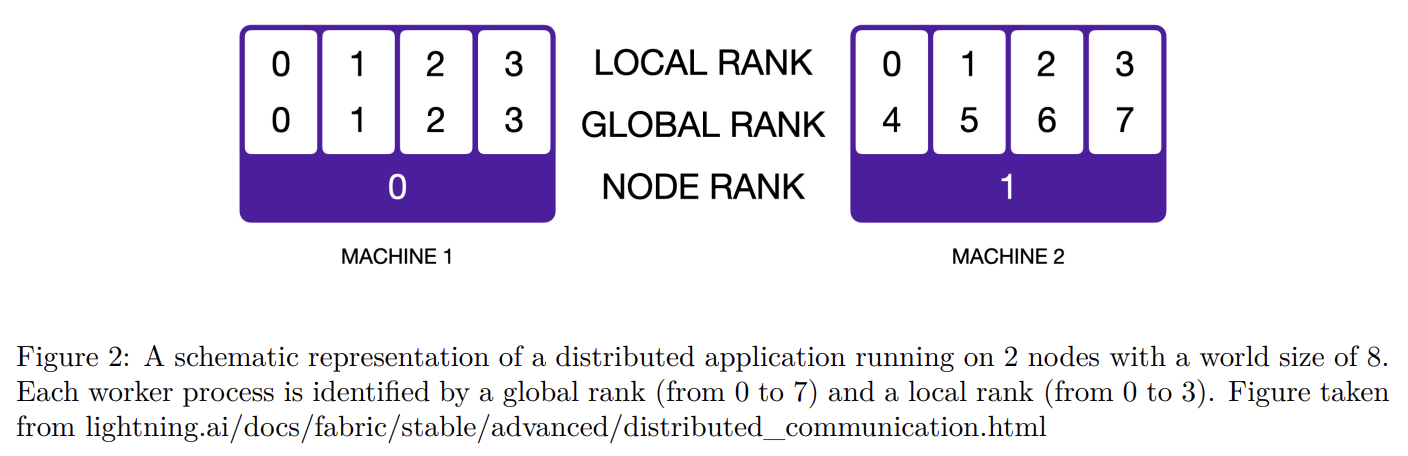
</center>

### Best Practices for Benchmarking Distributed Applications

Throughout this portion of the assignment you will be benchmarking distributed applications to better understand the overhead from communication. Here are a few best practices:
- Whenever possible, run benchmarks on the same machine to facilitate controlled comparisons.
- Perform several warm-up steps before timing the operation of interest. This is especially important for NCCL communication calls. 5 iterations of warmup is generally sufficient.
- Call `torch.cuda.synchronize()` to wait for CUDA operations to complete when benchmarking on GPUs. Note that this is necessary even when calling communication operations with `async_op=False`, which returns when the operation is queued on the GPU (as opposed to when the communication actually finishes). See [this issue](github.com/pytorch/pytorch/issues/68112#issuecomment-965932386) for more details.
- Timings may vary slightly across different ranks, so it’s common to aggregate measurements across ranks to improve estimates. You may find the all-gather collective (specifically the `dist.all_gather_object` function) to be useful for collecting results from all ranks.
- In general, debug locally with Gloo on CPU, and then as required in a given problem, benchmark with NCCL on GPU. Switching between the backends just involves changing the `init_process_group` call and tensor device casts.

### Problem: Single-Node Distributed Communication

Write a script to benchmark the runtime of the all-reduce operation in the single-node multi-process setup. The example code above may provide a reasonable starting point. Experiment with varying the following settings:
- Backend + device type: Gloo + CPU, NCCL + GPU.
- All-reduce data size: float32 data tensors ranging over 1MB, 10MB, 100MB, 1GB.
- Number of processes: 2, 4, or 6 processes.
- Resource requirements: Up to 6 GPUs. Each benchmarking run should take less than 5 minutes.

Provide plots and/or tables comparing the various settings, with 2-3 sentences of commentary about your results and thoughts about how the various factors interact.

## A Naive Implementation of Distributed Data Parallel Training

Now that we’ve seen the basics of writing distributed applications in PyTorch, let’s build a minimal implementation of distributed data parallel (DDP) training.

Data parallelism splits batches across multiple devices (e.g. GPUs), enabling training on large batch sizes that do not fit on a single device. For example, given four devices that can each handle a maximum batch size of 32, data parallel training would enable an effective batch size of 128.

Here are the steps for naively doing distributed data parallel training. Initially, each device constructs a (randomly-initialized) model. We use the broadcast collective communication operation to send the model parameters from rank 0 to all other ranks. At the start of training, each device holds an identical copy of the model parameters and optimizer states (e.g. the accumulated gradient statistics in Adam).
1. Given a batch with $n$ examples, the batch is sharded and each device receives $n/d$ disjoint examples (where $d$ is the number of devices used for data parallel training). $n$ should divide $d$, since the training time is bottlenecked by the slowest process.
2. Each device uses its local copy of the model parameters to run a forward pass on its $n/d$ examples and a backward pass to calculate the gradients. Note that at this point, each device holds the gradients computed from the $n/d$ examples it received.
3. We then use the all-reduce collective communication operation to average the gradients across the different devices, so each device holds the gradients averaged across all $n$ examples.
4. Next, each device runs an optimizer step to update its copy of the parameters—from the optimizer’s perspective, it is simply optimizing a local model. The parameters and optimizer states will stay in sync on all of the different devices since they all start from the same initial model and optimizer state and use the same averaged gradients for each iteration. At this point, we’ve completed a single training iteration and can repeat the process.

### Problem: Naive DDP

Write a script to naively perform distributed data parallel training by all-reducing individual parameter gradients after the backward pass. To verify the correctness of your DDP implementation, use it to train a small toy model on randomly-generated data and verify that its weights match the results from single-process training.

*Note:* If you’re having trouble writing this test, it might be useful to look at `tests/test_ddp_individual_parameters.py`.

### Problem: Naive DDP Benchmarking

In this naive DDP implementation, parameters are individually all-reduced across ranks after each backward pass. To better understand the overhead of data parallel training, create a script to benchmark your previously-implemented language model when trained with this naive implementation of DDP. Measure the total time per training step and the proportion of time spent on communicating gradients. Collect measurements in the single-node setting (1 node x 2 GPUs) for the XL model size described in the previous notebook. Provide a description of your benchmarking setup, along with the measured time per training iteration and time spent communicating gradients for each setting.

## Improving Upon the Minimal DDP Implementation

The minimal DDP implementation that we saw above has a couple of key limitations:
1. It conducts a separate all-reduce operation for every parameter tensor. Each communication call incurs overhead, so it may be advantageous to batch communication calls to minimize this overhead.
2. It waits for the backward pass to finish before communicating gradients. However, the backward pass is incrementally computed. Thus, when a parameter gradient is ready, it can immediately be communicated without waiting for the gradients of the other parameters. This allows us to overlap communication of gradients with computation of the backward pass, reducing the overhead of distributed data parallel training.

In this part of the assignment, we’ll address each of these limitations in turn and measure the impact on training speed.

### Reducing the Number of Communication Calls

Rather than issuing a communication call for each parameter tensor, let see if we can improve performance by batching the all-reduce. Concretely, we’ll take the gradients that we want to all-reduce, concatenate them into a single tensor, and then all-reduce the combined gradients across all ranks. It might be helpful to use `torch._utils._flatten_dense_tensors` and `torch._utils._unflatten_dense_tensors`.

#### Problem: Minimal DDP Flat Benchmarking

Modify your minimal DDP implementation to communicate a tensor with flattened gradients from all parameters. Compare its performance with the minimal DDP implementation that issues an `allreduce` for each parameter tensor under the previously-used conditions (1 node x 2 GPUs, XL model size as described before).

Provide the measured time per training iteration and time spent communicating gradients under distributed data parallel training with a single batched all-reduce call, along with a few sentences comparing the results when batching versus individually communicating gradients.

###  Overlapping Computation with Communication of Individual Parameter Gradients

While batching the communication calls might help lower the overhead associated with issuing a large number of small all-reduce operations, all of communication time still directly contributes to the overhead. To resolve this, we can take advantage of the observation that the backward pass incrementally computes gradients for each layer (starting from the loss and moving toward the input)—thus, we can all-reduce parameter gradients as soon as they’re ready, reducing the overhead of data parallel training by overlapping computation of the backward pass with communication of gradients.

We’ll start by implementing and benchmarking a distributed data parallel wrapper that asynchronously all-reduces individual parameter tensors as they become ready during the backward pass. The following pointers may be useful:

**Backward hooks:** To automatically call a function on a parameter after its gradient has been accumulated in the backward pass, you can use the `register_post_accumulate_grad_hook` function. See [here](pytorch.org/docs/stable/generated/torch.Tensor.register_post_accumulate_grad_hook.html) for more information and usage examples.

**Asynchronous communication:** All PyTorch collective communication operations support synchronous (`async_op=False`) and asynchronous execution (`async_op=True`). Synchronous calls will block until the collective operation is queued on the GPU. This does not mean that the CUDA operation is completed since CUDA operations are asynchronous. That being said, later function calls using the output will behave as
expected. *Note:* In advanced cases, if you are using multiple CUDA streams, you may need explicit synchronization across streams to ensure
that the output is ready for later operations. See [here](pytorch.org/docs/stable/notes/cuda.html#cuda-streams) for details.

In contrast, asynchronous calls will return a distributed request handle—as a result, when the function returns, the collective communication operation is not guaranteed to have been queued on GPU, let alone completed. To wait for the operation to be queued on GPU (and therefore for the output to be usable in later operations), you can call `handle.wait()` on the returned communication handle.

For example, the following two examples all-reduce each tensor in a list of tensors with either a synchronous or an asynchronous call:

```python
tensors = [torch.rand(5) for _ in range(10)]
# Synchronous, block until operation is queued on GPU.
for tensor in tensor:
    dist.all_reduce(tensor, async_op=False)
# Asynchronous, return immediately after each call and
# wait on results at the end.
handles = []
for tensor in tensors:
    handle = dist.all_reduce(tensor, async_op=True)
    handles.append(handle)
# ...
# Possibly execute other commands that don't rely on the all_reduce results
# ...
# Ensure that all-reduce calls were queued and
# therefore other operations depending on the
# all-reduce output can be queued.
for handle in handles:
    handle.wait()
handles.clear()
```

#### Problem: DDP Overlap Individual Parameters

Implement a Python class to handle distributed data parallel training. The class should wrap an arbitrary PyTorch `nn.Module` and take care of broadcasting the weights before training (so all ranks have the same initial parameters) and issuing communication calls for gradient averaging. We recommend the following public interface:

To use this class to perform distributed training, we’ll pass it a module to wrap, and then add a call to `finish_gradient_synchronization()` before we run `optimizer.step()` to ensure that the optimizer step, an operation that depends on the gradients, may be queued:

```python
model = ToyModel().to(device)
ddp_model = DDP(model)
for _ in range(train_steps):
    x, y = get_batch()
    logits = ddp_model(x)
    loss = loss_fn(logits, y)
    loss.backward()
    ddp_model.finish_gradient_synchronization()
    optimizer.step()
```

Implement a container class to handle distributed data parallel training. This class should overlap gradient communication and the computation of the backward pass. To test your DDP class, first implement the adapters `get_ddp_individual_parameters` and
`ddp_individual_parameters_on_after_backward` (the latter is optional, depending on your implementation you may not need it). Then, make sure it passes the test below. We recommend running the tests multiple times (e.g. 5) to ensure that it passes reliably.

In [ ]:
class DDP(nn.Module):
    def __init__(self, module):
        """
        Given an instantiated PyTorch nn.Module to be parallelized, construct a DDP container that will handle 
        gradient synchronization across ranks.
        """
        super().__init__()
        raise NotImplementedError
    
    def forward(self, *inputs, **kwargs):
        """Calls the wrapped module's forward() method with the provided positional and keyword arguments."""
        raise NotImplementedError
    
    def finish_gradient_synchronization(self):
        """When called, wait for asynchronous communication calls to be queued on GPU."""
        raise NotImplementedError

In [ ]:
def get_ddp_individual_parameters(module):
    """
    Returns a torch.nn.Module container that handles parameter broadcasting and gradient synchronization for
    distributed data parallel training.
    This container should overlaps communication with backprop computation by asynchronously communicating gradients as they are ready
    in the backward pass. The gradient for each parameter tensor is individually communicated.
    Args:
        module: torch.nn.Module
            Underlying model to wrap with DDP.
    Returns:
        Instance of a DDP class.
    """
    # For example: return DDPIndividualParameters(module)
    raise NotImplementedError

def ddp_individual_parameters_on_after_backward(ddp_model, optimizer):
    """
    Code to run after the backward pass is completed, but before we take an optimizer step.
    Args:
        ddp_model: torch.nn.Module
            DDP-wrapped model.
        optimizer: torch.optim.Optimizer
            Optimizer being used with the DDP-wrapped model.
    """
    # For example: ddp_model.finish_gradient_synchronization()
    raise NotImplementedError

test_ddp_individual_parameters(get_ddp_individual_parameters, ddp_individual_parameters_on_after_backward)

#### Problem: DDP Overlap Individual Parameters Benchmarking

1. Benchmark the performance of your DDP implementation when overlapping backward pass computation with communication of individual parameter gradients. Compare its performance with our previously-studied settings (the minimal DDP implementation that either issues an all-reduce for each parameter tensor, or a single all-reduce on the concatenation of all parameter tensors) with the same setup: 1 node, 2 GPUs, and the XL model size described before. Provide the measured time per training iteration when overlapping the backward pass
with communication of individual parameter gradients, with 1-2 sentences comparing the results.
2. Instrument your benchmarking code (using the 1 node, 2 GPUs, XL model size setup) with the Nsight profiler, comparing between the initial DDP implementation and this DDP implementation that overlaps backward computation and communication. Visually compare the two traces, and provide a profiler screenshot demonstrating that one implementation overlaps compute with
communication while the other doesn’t. Provide 2 screenshots (one from the initial DDP implementation, and another from this
DDP implementation that overlaps compute with communication) that visually show that communication is or isn’t overlapped with the backward pass.

### Overlapping Computation with Communication of Bucketed Parameter Gradients

In the previous section, we overlapped backprop computation with the communication of individual parameter gradients. However, we previously observed that batching communication calls can improve performance, especially when we have many parameter tensors (as is typical in deep Transformer models). Our previous attempt at batching sent all of the gradients at once, which requires waiting for the backward pass to finish. In this section, we’ll try to get the best of both worlds by organizing our parameters into buckets (reducing the number of total communication calls) and all-reducing buckets when each of their constituent tensors are ready (enabling us to overlap communication with computation).

#### Problem: DDP Overlap Bucketed

Implement a Python class to handle distributed data parallel training, using gradient bucketing to improve communication efficiency. The class should wrap an arbitrary input PyTorch `nn.Module` and take care of broadcasting the weights before training (so all ranks have the same initial parameters) and issuing bucketed communication calls for gradient averaging. We recommend the following interface:

Beyond the addition of a `bucket_size_mb` initialization parameter, this public interface matches the interface of our previous DDP implementation that individually communicated each parameter. We suggest allocating parameters to buckets using the reverse order of `model.parameters()`, since the gradients will become ready in approximately that order during the backward pass.

Implement a container class to handle distributed data parallel training. This class should overlap gradient communication and the computation of the backward pass. Gradient communication should be bucketed, to reduce the total number of communication calls. To test your implementation, complete the adapters `get_ddp_bucketed`, `ddp_bucketed_on_after_backward`, and `ddp_bucketed_on_train_batch_start` (the latter two are optional, depending on your implementation you may not need them).  Then, make sure they pass the test below. We recommend running the tests multiple times (e.g. 5) to ensure that it passes reliably.

In [ ]:
class DDPBucketed(nn.Module):
    def __init__(self, module, bucket_size_mb):
        """
        Given an instantiated PyTorch nn.Module to be parallelized, construct a DDP container that will handle 
        gradient synchronization across ranks. Gradient synchronization should be bucketed, with each bucket 
        holding at most bucket_size_mb of parameters.
        Args:
            module: nn.Module
            bucket_size_mb: float
        """
        super().__init__()
        raise NotImplementedError
    
    def forward(self, *inputs, *kwargs):
        """Calls the wrapped module's forward() method with the provided positional and keyword arguments."""
        raise NotImplementedError
    
    def finish_gradient_synchronization(self):
        """When called, wait for asynchronous communication calls to be queued on GPU."""
        raise NotImplementedError

In [ ]:
def get_ddp_bucketed(module, bucket_size_mb):
    """
    Returns a torch.nn.Module container that handles parameter broadcasting and gradient synchronization for
    distributed data parallel training.
    This container should overlaps communication with backprop computation by asynchronously communicating buckets of gradients as they 
    are ready in the backward pass.
    Args:
        module: torch.nn.Module
            Underlying model to wrap with DDP.
        bucket_size_mb: The bucket size, in megabytes. If None, use a single
            bucket of unbounded size.
    Returns:
        Instance of a DDP class.
    """
    raise NotImplementedError

def ddp_bucketed_on_after_backward(ddp_model, optimizer):
    """
    Code to run after the backward pass is completed, but before we take an optimizer step.
    Args:
        ddp_model: torch.nn.Module
            DDP-wrapped model.
        optimizer: torch.optim.Optimizer
            Optimizer being used with the DDP-wrapped model.
    """
    # For example: ddp_model.finish_gradient_synchronization()
    raise NotImplementedError

def ddp_bucketed_on_train_batch_start(ddp_model, optimizer):
    """
    Code to run at the very start of the training step.
    Args:
        ddp_model: torch.nn.Module
            DDP-wrapped model.
        optimizer: torch.optim.Optimizer
            Optimizer being used with the DDP-wrapped model.
    """
    raise NotImplementedError

test_ddp_bucketed(get_ddp_bucketed, ddp_bucketed_on_after_backward, ddp_bucketed_on_train_batch_start)

#### Problem: DDP Bucketed Benchmarking

1. Benchmark your bucketed DDP implementation using the same config as the previous experiments (1 node, 2 GPUs, XL model size), varying the maximum bucket size (1, 10, 100, 1000 MB). Compare your results to the previous experiments without bucketing—do the results align with your expectations? If they don’t align, why not? You may have to use the PyTorch profiler as necessary to better understand how communication calls are ordered and/or executed. What changes in the experimental setup would you expect to yield results that are aligned with your expectations? Provide the measured time per training iteration for various bucket sizes, along with a 3-4 sentence commentary about the results, your expectations, and potential reasons for any mismatch.
2. Assume that the time it takes to compute the gradients for a bucket is identical to the time it takes to communicate the gradient buckets. Write an equation that models the communication overhead of DDP (i.e., the amount of additional time spent after the backward pass) as a function of the total size (bytes) of the model parameters ($s$), the all-reduce algorithm bandwidth ($w$, computed as the size of each rank’s data divided by the time it takes to finish the all-reduce), the overhead (seconds) associated with each communication call ($o$), and the number of buckets ($n_b$). From this equation, write an equation for the optimal bucket size that minimizes DDP overhead. Provide an equation that models DDP overhead, and an equation for the optimal bucket size.

## 4D Parallelism

While much more complex in implementation, there are more axes along which we can parallelize our training process. Most commonly we discuss 5 methods of parallelism:
- **Data parallelism (DP):** Batches of data are split across multiple devices, and each device computes gradients for their own batch. These gradients must somehow be averaged across devices.
- **Fully-Sharded Data Parallelism (FSDP):** Optimizer states, gradients, and weights are split across devices. If we’re using only DP and FSDP, every device needs to gather the weight shards from all other devices before we can perform our forward or backward pass.
- **Tensor Parallelism (TP):** Activations are sharded across a new dimension, and each device computes the output results for their own shard. With Tensor Parallel we can either shard along the inputs or the outputs the operation we are sharding. Tensor Parallelism can be used effectively together with FSDP if we shard the weights and the activations along corresponding dimensions.
- **Pipeline Parallelism (PP):** The model is split layerwise into multiple stages, where each stage is run on a different device.
- **Expert Parallelism (EP):** We separate experts (in Mixture-of-Experts models) onto different devices, and each device computes the output results for their own expert.

Typically, we always combine FSDP and TP, so we can think of them as a single axis of parallelism. This leaves us with 4 axes of parallelism: DP, FSDP/TP, PP, and EP. We will also focus on dense models (not MoEs) and so will not discuss EP further.

When reasoning about distributed training, we often describe our cluster as a *mesh* of devices, where the axes of the mesh are the axes along which we define our parallelism. For instance, if we have 16 GPUs and a model that is much larger than we can fit on a single device, we might be inclined to organize our mesh into a 4 × 4 grid of GPUs, where the first dimension represents DP, and the second dimension represents combined FSDP and TP.

See the overview in Part 5 of the TPU Scaling Book *(Austin et al. 2025)* for more details on how these methods work and how to derive their communication and memory costs (this will be especially helpful to tackle the problem below). For a more detailed pipeline parallel discussion, see The Ultra-Scale Playbook Appendix *(Nouamane Tazi, 2025)*. The rest of this book also has a lot of other information you might find useful.

### Problem: Communication Accounting

Consider a new model config, XXL, with `d_model=16384`, `d_ff=53248`, and `num_blocks=126`. Because for very large models, the vast majority of FLOPs are in the feedforward networks, we make some simplifying assumptions. First, we omit attention, input embeddings, and output linear layers. Then, we assume that each FFN is simply two linear layers (ignoring the activation function), where the first has input size `d_model` and output size `d_ff`, and the second has input size `d_ff`and output size `d_model`. Your model consists of `num_blocks` blocks of these two linear layers. Don’t do any activation checkpointing, and keep your activations and gradient communications in BF16, while your accumulated gradients, master weights and optimizer state should be in FP32.
1. How much memory would it take to store the master model weights, accumulated gradients and optimizer states in FP32 on a single device? How much memory is saved for backward (these will be in BF16)? How many H100 80GB GPUs worth of memory is this? Provide the calculations.
2. Now assume your master weights, optimizer state, gradients and half of your activations (in practice every second layer) are sharded across $N_{FSDP}$ devices. Write an expression for how much memory this would take per device. What value does $N_{FSDP}$ need to be for the total memory cost to be less than 1 `v5p` TPU (95GB per device)? Provide the calculations and a one-sentence response.
3. Consider only the forward pass. Use the communication bandwidth of $W_{ici} = 2 \cdot 9 \cdot 1010$ and FLOPS/s of $C = 4.6 \cdot 1014$ for TPU `v5p` as given in the TPU Scaling Book. Following the notation of the Scaling Book, use $M_X = 2$, $M_Y = 1$ (a 3D mesh), with $X = 16$ being your FSDP dimension, and $Y = 4$ being your TP dimension. At what per-device batch size is this model compute bound? What is the overall batch size in this setting? Provide the calculations.
4. In practice, we want the overall batch size to be as small as possible, and we also always use our compute effectively (in other words we want to never be communication bound). What other tricks can we employ to reduce the batch size of our model but retain high throughput? Provide a one-paragraph response. Back up your claims with references and/or equations.

## Optimizer State Sharding

Distributed data parallel training is conceptually simple and often very effective, but requires each rank to hold a distinct copy of the model parameters and optimizer state. This redundancy can come with significant memory costs. For example, the AdamW optimizer maintains two floats per parameter, meaning that it consumes twice as much memory as the model weights. *Rajbhandari et al. (2020)* describe several methods for reducing this redundancy in data-parallel training by partitioning the (1) optimizer state, (2) gradients, and (3) parameters across ranks, communicating them between workers as necessary.

In this part of the assignment, we’ll reduce per-rank memory consumption by implementing a simplified version of optimizer state sharding. Rather than keeping the optimizer states for all parameters, each rank’s optimizer instance will only handle a subset of the parameters (approximately `1 / world_size`). When each rank’s optimizer takes an optimizer step, it’ll only update the subset of model parameters in its shard. Then, each rank will broadcast its updated parameters to the other ranks to ensure that the model parameters remain synchronized after each optimizer step.

### Problem: Optimizer State Sharding

Implement a Python class to handle optimizer state sharding. The class should wrap an arbitrary input PyTorch `optim.Optimizer` and take care of synchronizing updated parameters after each optimizer step. We recommend the following public interface:

Implement a container class to handle optimizer state sharding. To test your sharded optimizer, first implement the adapter `get_sharded_optimizer`. Then, make sure it passes the test below. We recommend running the tests multiple times (e.g., 5) to ensure that it passes reliably.

In [ ]:
class OptimizerStateSharding(torch.optim.Optimizer):
    def __init__(self, params, optimizer_clas, **kwargs):
        """
        Initializes the sharded state optimizer.
        Args:
            params. Collection of parameters to be optimized (or parameter groups, in case the user wants to use 
                different hyperparameters, such as learning rates, for different parts of the model); 
                these parameters will be sharded across all the ranks.
            optimizer_cls: Type[Optimizer]. Specifies the type of optimizer to be wrapped (e.g. optim.AdamW).
            **kwargs. Any remaining keyword arguments are forwarded to the constructor of the optimizer_cls.
        """
        super().init()
        raise NotImplementedError
    
    def step(self, closure, **kwargs):
        """
        Calls the wrapped optimizer's step() method with the provided closure and keyword args.
        After updating the parameters, synchronize with the other ranks.
        """
        raise NotImplementedError
    
    def add_param_group(self, param_group):
        """
        Add a parameter group to the sharded optimizer.
        This is called during construction of the sharded optimizer by the super-class constructor and may also 
        be called during training (e.g. for gradually unfreezing layers in a model). 
        As a result, this method should handle assigning the model’s parameters among the ranks.
        Args:
            param_group: dict[str, Any]
        """
        raise NotImplementedError

In [ ]:
def get_sharded_optimizer(params, optimizer_cls, **kwargs):
    """
    Returns a torch.optim.Optimizer that handles optimizer state sharding of the given optimizer_cls on the provided parameters.
    Arguments:
        params: Iterable. an Iterable of :class:torch.Tensor or :class:dict s giving all parameters, 
            which will be sharded across ranks.
        optimizer_class: :class:torch.nn.Optimizer. The class of the local optimizer.
        **kwargs: keyword arguments to be forwarded to the optimizer constructor.
    Returns:
        Instance of sharded optimizer.
    """
    raise NotImplementedError

test_sharded_optimizer(get_sharded_optimizer)

### Problem: Optimizer State Sharding

Now that we’ve implemented optimizer state sharding, let’s analyze its effect on the peak memory usage during training and its runtime overhead.
1. Create a script to profile the peak memory usage when training language models with and without optimizer state sharding. Using the standard configuration (1 node, 2 GPUs, XL model size), report the peak memory usage after model initialization, directly before the optimizer step, and directly after the optimizer step. Do the results align with your expectations? Break down the memory usage in each setting (e.g., how much memory for parameters, how much for optimizer states, etc.). Give a 2-3 sentence response with peak memory usage results and a breakdown of how the memory is divided between different model and optimizer components.
2. How does our implementation of optimizer state sharding affect training speed? Measure the time taken per iteration with and without optimizer state sharding for the standard configuration (1 node, 2 GPUs, XL model size). Give a 2-3 sentence response with your timings.
3. How does our approach to optimizer state sharding differ from ZeRO stage 1 (described as ZeRO-DP $P_{os}$ in *Rajbhandari et al., 2020*)? Give a 2-3 sentence summary of any differences, especially those related to memory and communication volume.